## Potrzebne biblioteki

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim

import torchvision
from torchvision import transforms, datasets

## Wybór urządzenia

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## Zbiór danych

In [3]:
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.ImageFolder("trafic_32", transform=transform)
# dataloader = data.DataLoader(dataset, batch_size=128, shuffle=True)

## Rozkład próbek w klasach

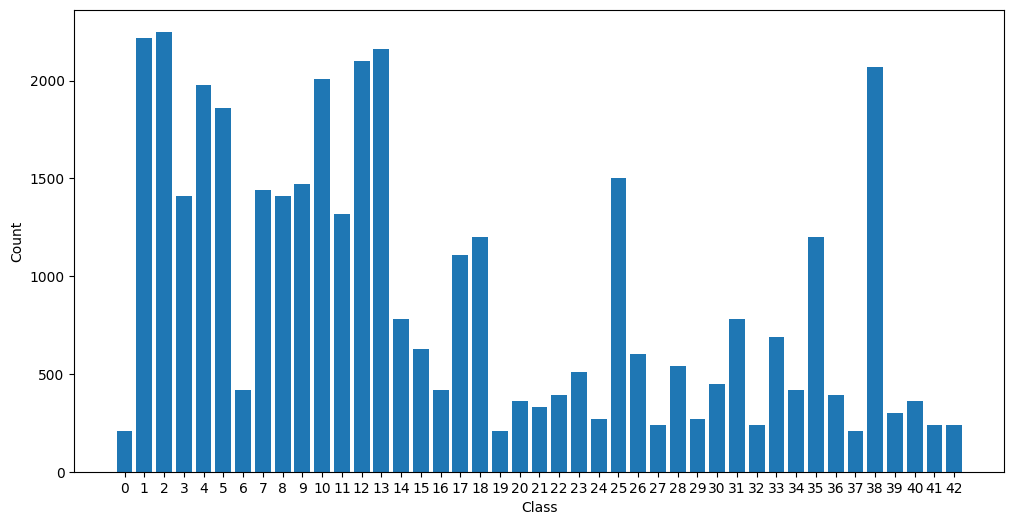

In [4]:
class_counts = Counter(dataset.targets)

classes = list(class_counts.keys())
counts = [class_counts[c] for c in classes]

plt.figure(figsize=(12, 6))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(classes)
plt.show()

## Ważenie próbek

In [5]:
counts = np.bincount(dataset.targets)
weights = 1.0 / counts

sample_weights = [weights[t] for t in dataset.targets]

sampler = data.WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

dataloader = data.DataLoader(dataset, batch_size=128, sampler=sampler)

## Architektura GAN

In [6]:
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Discriminator, self).__init__()

        self.conv_1 = nn.Conv2d(input_dim, hidden_dim, 4, 2, 1, bias=False)

        self.conv_2 = nn.Conv2d(hidden_dim, hidden_dim * 2, 4, 2, 1, bias=False)
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 4, 2, 1, bias=False)
        self.bn_3 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_out = nn.Conv2d(hidden_dim * 4, 1, 4, 1, 0, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.act(self.conv_1(x))
        x = self.act(self.bn_2(self.conv_2(x)))
        x = self.act(self.bn_3(self.conv_3(x)))

        x = torch.sigmoid(self.conv_out(x))
        return torch.flatten(x)


class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Generator, self).__init__()

        self.conv_1 = nn.ConvTranspose2d(
            latent_dim, hidden_dim * 4, 4, 1, 0, bias=False
        )
        self.bn_1 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_2 = nn.ConvTranspose2d(
            hidden_dim * 4, hidden_dim * 2, 4, 2, 1, bias=False
        )
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.ConvTranspose2d(
            hidden_dim * 2, hidden_dim, 4, 2, 1, bias=False
        )
        self.bn_3 = nn.BatchNorm2d(hidden_dim)

        self.conv_4 = nn.ConvTranspose2d(hidden_dim, output_dim, 4, 2, 1, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.act(self.bn_1(self.conv_1(x)))
        h = self.act(self.bn_2(self.conv_2(h)))
        h = self.act(self.bn_3(self.conv_3(h)))

        x_hat = torch.sigmoid(self.conv_4(h))
        return x_hat

## Inicjalizacja sieci

In [7]:
latent_dim = 128
hidden_dim = 64
channels = 3
num_classes = len(dataset.class_to_idx)

generator = Generator(
    latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=channels
).to(device)

discriminator = Discriminator(input_dim=channels, hidden_dim=hidden_dim).to(device)


generator_optimizer = torch.optim.Adam(
    generator.parameters(), lr=0.0004, betas=(0.5, 0.999)
)
generator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=generator_optimizer, gamma=0.99
)
discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999)
)
discriminator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=discriminator_optimizer, gamma=0.99
)

criterion = nn.BCELoss()

## Pętla treningowa

Epoch: 0, discrimiantor fake error: 0.47, discriminator real acc: 0.521


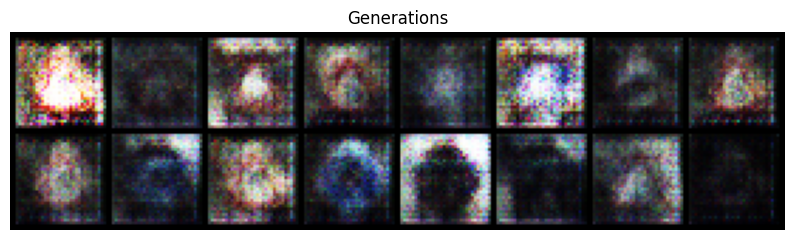

Epoch: 1, discrimiantor fake error: 0.46, discriminator real acc: 0.535
Epoch: 2, discrimiantor fake error: 0.445, discriminator real acc: 0.549
Epoch: 3, discrimiantor fake error: 0.425, discriminator real acc: 0.571
Epoch: 4, discrimiantor fake error: 0.398, discriminator real acc: 0.598
Epoch: 5, discrimiantor fake error: 0.372, discriminator real acc: 0.622
Epoch: 6, discrimiantor fake error: 0.345, discriminator real acc: 0.651
Epoch: 7, discrimiantor fake error: 0.317, discriminator real acc: 0.68
Epoch: 8, discrimiantor fake error: 0.297, discriminator real acc: 0.7
Epoch: 9, discrimiantor fake error: 0.277, discriminator real acc: 0.721
Epoch: 10, discrimiantor fake error: 0.258, discriminator real acc: 0.738


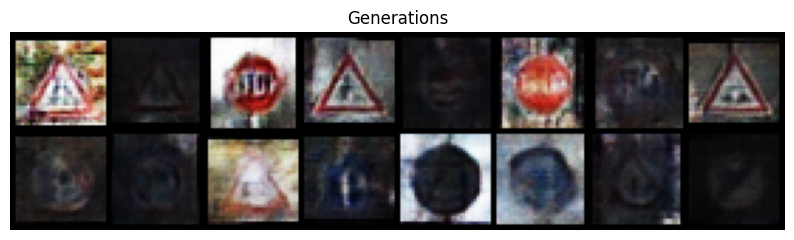

Epoch: 11, discrimiantor fake error: 0.244, discriminator real acc: 0.754
Epoch: 12, discrimiantor fake error: 0.235, discriminator real acc: 0.763


KeyboardInterrupt: 

In [9]:
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

G_losses = []
D_losses = []
num_epochs = 100
for epoch in range(num_epochs):
    discriminator_fake_acc = []
    discriminator_real_acc = []
    for i, data in enumerate(dataloader, 0):
        ####################
        # Update D network #
        ####################

        ## Train with all-real batch
        discriminator_optimizer.zero_grad()

        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.ones((b_size,), dtype=torch.float, device=device)

        output = discriminator(real_images).view(-1)
        error_discriminator_real = criterion(output, label)
        discriminator_real_acc.append(output.mean().item())

        ## Train with all-fake batch
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)

        fake_images = generator(noise)
        label_fake = torch.zeros((b_size,), dtype=torch.float, device=device)

        output = discriminator(fake_images.detach()).view(-1)
        error_discriminator_fake = criterion(output, label_fake)
        discriminator_fake_acc.append(output.mean().item())

        error_discriminator = error_discriminator_real + error_discriminator_fake
        error_discriminator.backward()

        discriminator_optimizer.step()

        ####################
        # Update G network #
        ####################
        generator_optimizer.zero_grad()
        label = torch.ones((b_size,), dtype=torch.float, device=device)

        output = discriminator(fake_images).view(-1)
        error_generator = criterion(output, label)
        error_generator.backward()

        generator_optimizer.step()

        G_losses.append(error_generator.item())
        D_losses.append(error_discriminator.item())

    print(
        f"Epoch: {epoch}, discrimiantor fake error: {np.mean(discriminator_fake_acc):.3}, discriminator real acc: {np.mean(discriminator_real_acc):.3}"
    )
    generator_scheduler.step()
    discriminator_scheduler.step()
    if epoch % 10 == 0:
        with torch.no_grad():
            fake = generator(fixed_noise).detach().cpu()
        grid = torchvision.utils.make_grid(fake)
        grid = grid.permute(1, 2, 0)
        plt.figure(figsize=(10, 10))
        plt.title(f"Generations")
        plt.imshow(grid)
        plt.axis("off")
        plt.show()